# 🧠 Exploratory Data Analysis (EDA): Asking Better Questions

## 🎯 Lesson Objectives

By the end of this lesson, you will be able to:

- Understand that **EDA is a process of discovery**, not a fixed sequence of steps  
- Calculate and interpret **measures of central tendency** (mean, median)  
- Evaluate **spread and variability** using standard deviation  
- Explore **categorical variables** using counts and proportions  
- Investigate relationships between variables using **covariance and correlation**  
- Use **Pandas tools** to support and scale your analysis  
- Translate your findings into **clear, data-driven insights**

---

## ❓ Guiding Question

> **What factors influence the price of a diamond?**

We will use this question to guide our exploration of the dataset.

But before jumping into code, take a moment to think:

- What variables might impact price?
- Are some variables more important than others?
- How would you begin to investigate this?

---

## 🔍 What is EDA?

Exploratory Data Analysis (EDA) is not a checklist.

It’s not:
- “Run `.describe()`”
- “Make a few plots”
- “Move on”

Instead, EDA is the process of:

> **Asking questions, investigating patterns, and uncovering what your data is actually telling you.**

---

## 🔁 How We’ll Approach This

Rather than following a rigid sequence, we’ll explore the dataset by asking:

- What does a single variable look like?  
- How spread out is the data?  
- What categories exist, and how common are they?  
- Do variables move together?  
- Are there relationships worth investigating further?  

Each step builds toward answering our guiding question.

---

## 💡 Key Mindset

> **EDA is iterative.**

You won’t always know what to look for at the start.

You’ll:
- Ask a question  
- Explore the data  
- Discover something new  
- Ask a better question  

That’s the process.

---

## 🚀 Let’s Begin

We’ll start by exploring individual variables, then gradually build toward understanding relationships in the data.



In [1]:
# imports
from pathlib import Path
import pandas as pd

In [3]:
# Set path variables
RAW_DATA = Path("..") / "data" / "raw" 
PROCESSED_DATA = Path("..") / "data" / "processed"

In [4]:
# read in diamonds dataset

diamonds = pd.read_csv(RAW_DATA / "diamonds.csv")

diamonds.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


### Manually calculate summary statistics

We've seen `.describe()` and seen that we get some summary statistics.

Let's calculate them to get a deeper understanding of them.

---

## 📊 Key Statistics (Quick Reference + Intuition)

Below are the core statistics we’ll use in this lesson. Focus on **what they measure**, not memorizing formulas.

---

### Mean (Average)

$$
\bar{x} = \frac{1}{n} \sum_{i=1}^{n} x_i
$$

**What it tells you:**  
The average value of the dataset.

**Why it matters:**  
Gives a sense of what is “typical,” but can be influenced by outliers.

---

### Median (Middle Value)

$$
\text{Median}(X) = x_{\left(\frac{n+1}{2}\right)} \quad \text{(for sorted data, odd } n\text{)}
$$

**What it tells you:**  
The middle value when the data is sorted.

**Why it matters:**  
More robust to outliers than the mean.

---

### Variance (Spread)

$$
s^2 = \frac{1}{n - 1} \sum_{i=1}^{n} (x_i - \bar{x})^2
$$

**What it tells you:**  
How spread out the data is from the mean.

**Why it matters:**  
Helps you understand how consistent or variable your data is.

---

### Standard Deviation

$$
s = \sqrt{\frac{1}{n - 1} \sum_{i=1}^{n} (x_i - \bar{x})^2}
$$

**What it tells you:**  
The typical distance from the mean (in the original units).

**Why it matters:**  
Easier to interpret than variance because it’s in the same units as the data.

---

### Covariance (Relationship Direction)

$$
\mathrm{Cov}(X, Y) = \frac{1}{n - 1} \sum_{i=1}^{n} (x_i - \bar{x})(y_i - \bar{y})
$$

**What it tells you:**  
Whether two variables move together.

- Positive → move together  
- Negative → move in opposite directions  

**Why it matters:**  
Helps detect relationships, but is hard to interpret due to units.

---

### Correlation (Relationship Strength)

$$
r = \frac{\sum_{i=1}^{n} (x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum_{i=1}^{n} (x_i - \bar{x})^2} \sqrt{\sum_{i=1}^{n} (y_i - \bar{y})^2}}
$$

**What it tells you:**  
The strength and direction of a linear relationship.

- **1** → perfect positive relationship  
- **-1** → perfect negative relationship  
- **0** → no linear relationship  

**Why it matters:**  
Unlike covariance, correlation is **scaled and comparable across variables**.

---

## ⚠️ Why Does Pandas Use \( n - 1 \)?

You may notice that variance, standard deviation, and covariance use:

$$
n - 1
$$

instead of:

$$
n
$$

This is called **sample statistics**.

### The Key Idea

> We usually don’t have the entire population—we have a **sample** of the data.

Using \( n - 1 \) (instead of \( n \)) slightly increases the estimate of variability to account for the fact that we are working with incomplete data.

This adjustment is known as **Bessel’s Correction**.

---

### Why This Matters for You

- Pandas defaults to **sample statistics** (`ddof=1`)  
- Your manual calculations may have used **population formulas** (`n`)  
- This can lead to **slightly different results**

---

### In Practice

```python
df['price'].var()        # sample variance (default)
df['price'].std()        # sample standard deviation

df['price'].var(ddof=0)  # population variance
df['price'].std(ddof=0)  # population standard deviation

In [ ]:
# .describe()

In [6]:
# grab prices and convert to a list
prices = diamonds['price'].tolist()

# prices

In [7]:
# to calculate the mean, we sum up every observation and divide by the total number of observations
mean_price = sum(prices) / len(prices)

In [8]:
# The median is what the middle value of our variable.
# To calculate the median, we need to sort our data first
sorted_prices = sorted(prices)

In [9]:
# Then find the middle number
median_price = sorted_prices[len(prices)//2]

In [10]:
print(f"The average diamond price is: ${mean_price}")
print(f"The median diamond price is: ${median_price}")

The average diamond price is: $3932.799721913237
The median diamond price is: $2401


In [11]:
# now compare to pandas
print(diamonds['price'].mean())
print(diamonds['price'].median())

3932.799721913237
2401.0


## Why do we care?

The mean is the average price.

The median is the typical transaction.

What is a key difference between the mean and median? 

* The mean can be influenced by extreme values!



---

### 2. Measures of spread

Variance and Standard Deviation are two ways to tell the spread of a dataset.

Standard Deviation measures how far values typically are from the mean (average).

A **low** stdev means our data is pretty consistent.

A **high** stdev means our data is fairly volatile.

In [13]:
# A quick example to showcase how two datasets can have the same mean, but different spread
low_spread = [100, 102, 98, 101, 99]
high_spread = [50, 150, 30, 170, 100]

print(f"Average in low spread: {sum(low_spread) / len(low_spread)}")
print(f"Average in high spread: {sum(high_spread) / len(high_spread)}")

Average in low spread: 100.0
Average in high spread: 100.0


In [14]:
# Let's calculate stdev and variance by hand
mean_price = diamonds['price'].mean()

squared_diffs = (diamonds['price'] - mean_price) ** 2
variance = squared_diffs.mean()
stdev = variance**0.5

In [37]:
stdev

3989.4027576288736

We square the differences so negatives don't cancel out, and take the square root to bring it back in the original units.

---

Mean tells you what's typical.

Standard deviation tells you how reliable that typical value is.

In [15]:
# let's revisit .describe()

diamonds['price'].describe()

count    53940.000000
mean      3932.799722
std       3989.439738
min        326.000000
25%        950.000000
50%       2401.000000
75%       5324.250000
max      18823.000000
Name: price, dtype: float64

Look at the std relative to the mean.

If we have a large std relative to the mean, we have a wide range for that variable!

This means that our distribution is likely *skewed* and the median is a better measure of the central tendency of diamond prices.

---

## 3. Understanding Relationships between two variables

Covariance is a measure of how two variables move in relation to each other.

* Positive -> move together
* Negative -> move opposite
* Near zero -> no relationship

In [16]:
# let's measure covariance of carat size and price
x = diamonds["carat"]
y = diamonds["price"]

In [17]:
# calculate the average of both
mean_x = x.mean()
mean_y = y.mean()

In [23]:
# now caluclate the covariance
cov = sum((xi - mean_x)*(yi-mean_y) for xi, yi in zip(x, y)) / len(x)

print(f"The covariance of carat size and price is {cov:.2f}")

The covariance of carat size and price is 1742.73


In [22]:
# check with pandas
diamonds[['price', 'carat']].cov()

,price,carat
price,1.591563e+07,1742.765364
carat,1.742765e+03,0.224687


## Covariance vs Correlation

Covariance measures how two variables move together.

If both variables increase together → covariance is positive

If one increases while the other decreases → covariance is negative

**However, covariance is hard to interpret because it depends on the units of the variables.**

For example:

`carat` is measured in weight

`price` is measured in dollars

This means the covariance value is tied to those units, making it difficult to compare across different variable pairs.

---


### Why is correlation more useful?

Correlation takes covariance and scales it into a standard range.

Correlation is a *standardized* version of covariance.

It is always between -1 and 1, regardless of the units of the variables.

This makes correlation much easier to interpret and compare.

How to interpret correlation:
* 1 → perfect positive relationship (both variables increase together)
* -1 → perfect negative relationship (one increases, the other decreases)
* 0 → no linear relationship

### The Key Idea

* Covariance tells you the direction of a relationship.
* Correlation tells you the direction and strength in a way that is easy to compare.

In [24]:
# Let's calculate it for price and carats
corr = cov / (x.std() * y.std())

print(f"The correlation between carat size and price is: {corr}")

The correlation between carat size and price is: 0.9215742157040211


In [25]:
diamonds[['price', 'carat']].corr()

,price,carat
price,1.000000,0.921591
carat,0.921591,1.000000


How would you describe the relationship between price and carat?

---

So far we've seen numeric variables.

For numeric variables we ask, "What's typical, and how spread out is it?"

What about categorical variables?

For these we ask, "what exists, and how common is each category?"

In [26]:
# Remember .value_counts(), let's see it on our cut column
diamonds['cut'].value_counts()

cut
Ideal        21551
Premium      13791
Very Good    12082
Good          4906
Fair          1610
Name: count, dtype: int64

`.value_counts()` reports the raw frequency of each category.

What is a better thing to report? The proportion of each category, ie. what percentage is each one.

To find this, we set `normalize=True` inside of `.value_counts()`

In [27]:
diamonds['cut'].value_counts(normalize=True)

cut
Ideal        0.399537
Premium      0.255673
Very Good    0.223990
Good         0.090953
Fair         0.029848
Name: proportion, dtype: float64

### Counts vs Proportions

What is more interpretable?

- We have **21,551 Ideal cut diamonds**
- **~40% of our diamonds are Ideal cut**

Both are correct—but they answer slightly different questions:

- **Raw counts** tell us how many observations we have  
- **Proportions** tell us how common something is relative to the dataset  

> In most cases, proportions are easier to interpret and compare—especially across datasets of different sizes.

---

### Revisiting `.groupby()`

So far, we've looked at variables **individually**.

Now we want to ask a deeper question:

> How does one variable behave *across categories*?

This is where `.groupby()` becomes powerful.

`.groupby()` splits the dataset by a categorical variable, and then applies an aggregation to another variable within each group.

For example:

```python
df.groupby('cut')['price'].mean()

In [28]:
diamonds.groupby('cut')['price'].mean()

cut
Fair         4358.757764
Good         3928.864452
Ideal        3457.541970
Premium      4584.257704
Very Good    3981.759891
Name: price, dtype: float64

---

## 4. Quick Visualizations.

We'll cover visualization more in-depth in a later lesson where we'll see two common visualization libraries in Python, `matplotlib` and `seaborn`. 

For now, just know that `pandas` uses `matplotlib` under the hood for plotting, similar to how it uses `numpy` for calculations.

Let's visualize some of our variables we've looked at this lesson.

In [29]:
# first, call .describe() again on price

diamonds['price'].describe()

count    53940.000000
mean      3932.799722
std       3989.439738
min        326.000000
25%        950.000000
50%       2401.000000
75%       5324.250000
max      18823.000000
Name: price, dtype: float64

If we plotted all the diamond prices, what do you think that "distribution" would look like?

**hint**: look at the std and then look at the mean. 

<Axes: title={'center': 'Diamond Price Distribution'}, ylabel='Frequency'>

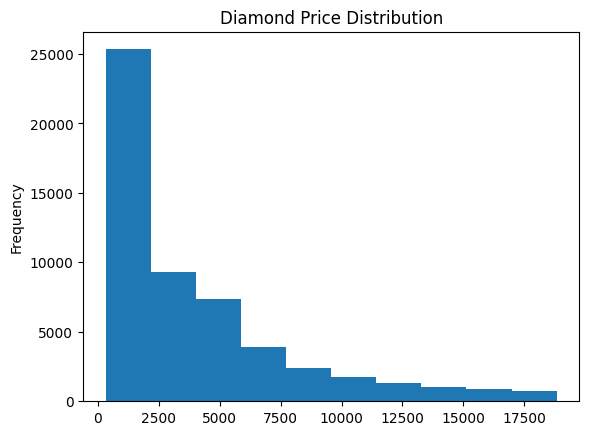

In [30]:
# plot diamond price distn
diamonds['price'].plot(kind='hist', title='Diamond Price Distribution')

In [38]:
# Can we visualize the relationship between carat and price?
diamonds[['carat', 'price']].corr()

,carat,price
carat,1.000000,0.921591
price,0.921591,1.000000


<Axes: title={'center': 'Carat vs. Price'}, xlabel='carat', ylabel='price'>

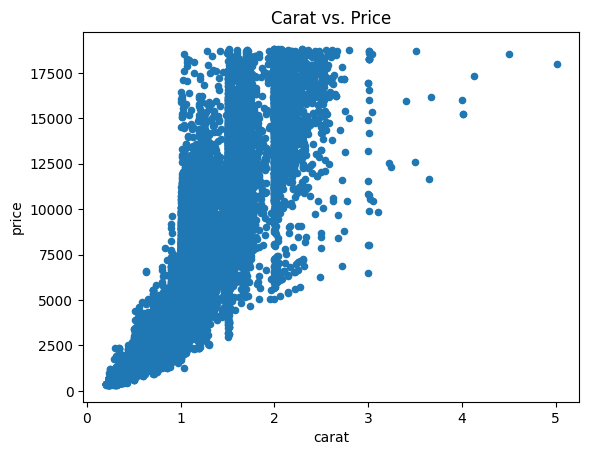

In [31]:
# We saw they're strongly, positively correlated. What will this plot look like?
diamonds.plot(kind='scatter', x='carat', y='price', title='Carat vs. Price')

In [32]:
# let's visualize the proportion of cuts
diamonds['cut'].value_counts(normalize=True)

cut
Ideal        0.399537
Premium      0.255673
Very Good    0.223990
Good         0.090953
Fair         0.029848
Name: proportion, dtype: float64

<Axes: title={'center': 'Proportion of Diamond Cuts'}, xlabel='cut'>

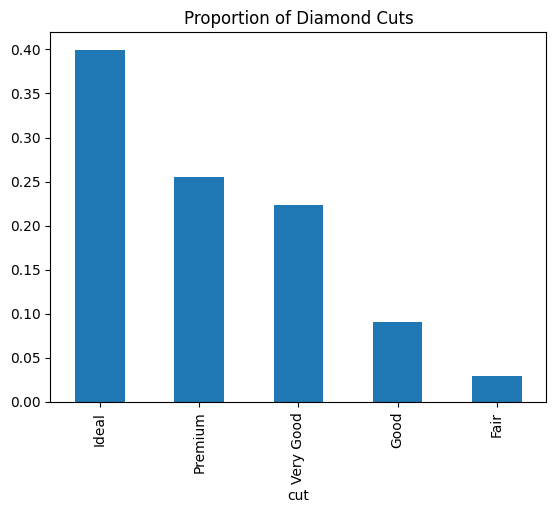

In [33]:
# now visualize it
diamonds['cut'].value_counts(normalize=True).plot(kind='bar', title='Proportion of Diamond Cuts')

In [34]:
# What about the average price per diamond cut?
diamonds.groupby('cut')['price'].mean()

cut
Fair         4358.757764
Good         3928.864452
Ideal        3457.541970
Premium      4584.257704
Very Good    3981.759891
Name: price, dtype: float64

<Axes: title={'center': 'Average Price per Diamond Cut'}, xlabel='cut'>

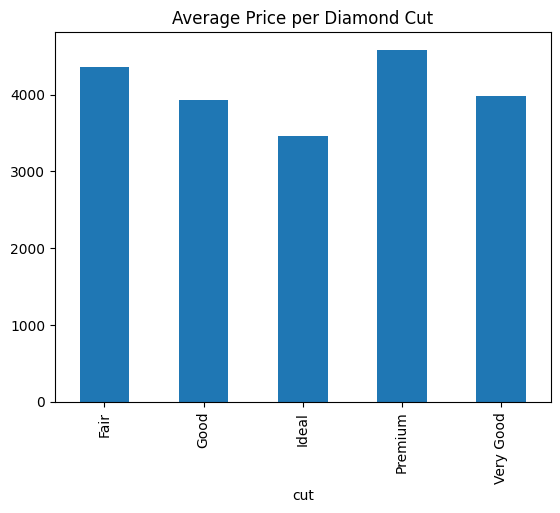

In [36]:
# chaining pandas methods
diamonds.groupby('cut')['price'].mean().plot(kind='bar', title='Average Price per Diamond Cut')

---

## YOUR TURN

Investigate some of the different variables in our dataset.

Think of how to use correlation and `.groupby()` to answer questions you're interested in!